In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

df = pd.read_csv("../data_processed/master_test_dataset.csv")
df
# Clean the dataset 

df["date"] = pd.to_datetime(df["date"])

In [2]:
# Country filtering
country = 'India'

# Timeline Filtering
start_year = 2015
end_year = 2025

# Filtering

df_country = df[(df['team1'] == country) | (df['team2'] == country)]
df_country = df_country[(df_country['year'] >= start_year) & (df_country['year'] <= end_year)].copy()

df_country

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,opponent
13,1022593,West Indies,India,"Sir Vivian Richards Stadium, North Sound",Antigua,2016-07-21,India,92.0,NaN,2016,Win,West Indies,West Indies,India,West Indies
14,1022595,West Indies,India,"Sabina Park, Kingston",Jamaica,2016-07-30,NaN,NaN,NaN,2016,Draw,West Indies,West Indies,India,West Indies
15,1022597,West Indies,India,"Darren Sammy National Cricket Stadium, Gros Islet",St Lucia,2016-08-09,India,237.0,NaN,2016,Win,West Indies,West Indies,India,West Indies
16,1022599,West Indies,India,"Queen's Park Oval, Port of Spain",Trinidad,2016-08-18,NaN,NaN,NaN,2016,Draw,West Indies,West Indies,India,West Indies
21,1030213,India,New Zealand,Green Park,Kanpur,2016-09-22,India,197.0,NaN,2016,Win,India,India,New Zealand,New Zealand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,895777,Sri Lanka,India,Sinhalese Sports Club Ground,Colombo,2015-08-28,India,117.0,NaN,2015,Win,Sri Lanka,Sri Lanka,India,Sri Lanka
852,903603,India,South Africa,"Punjab Cricket Association Stadium, Mohali",Chandigarh,2015-11-05,India,108.0,NaN,2015,Win,India,India,South Africa,South Africa
853,903605,India,South Africa,M Chinnaswamy Stadium,Bangalore,2015-11-14,NaN,NaN,NaN,2015,Draw,India,India,South Africa,South Africa
854,903607,India,South Africa,"Vidarbha Cricket Association Stadium, Jamtha",Nagpur,2015-11-25,India,124.0,NaN,2015,Win,India,India,South Africa,South Africa


In [3]:
df["series_key"] = df.apply(
    lambda row: "_".join(sorted([row["team1"], row["team2"]])),
    axis=1
)

df["date_diff"] = df.groupby("series_key")["date"].diff().dt.days

#df["date_diff"]

Group Matches as series by Date logic

In [4]:
df["new_series"] = (df["date_diff"] > 15) | (df["date_diff"].isna())

df["series_id"] = df.groupby("series_key")["new_series"].cumsum()

In [5]:
df[df["series_key"] == "England_India"][["date", "date_diff", "series_id"]]

,date,date_diff,series_id
31,2016-11-09,NaN,1
32,2016-11-17,8.0,1
33,2016-11-26,9.0,1
34,2016-12-08,12.0,1
35,2016-12-16,8.0,1
74,2018-08-01,593.0,2
75,2018-08-09,8.0,2
76,2018-08-18,9.0,2
77,2018-08-30,12.0,2
78,2018-09-07,8.0,2


Series Winner Mapping

In [6]:
series_results = df.groupby(
    ["series_id","series_key","winner"]
)["match_id"].count().reset_index()

series_results

,series_id,series_key,winner,match_id
0,1,Australia_Bangladesh,Australia,3
1,1,Australia_Bangladesh,Bangladesh,1
2,1,Australia_England,Australia,4
3,1,Australia_ICC World XI,Australia,1
4,1,Australia_India,Australia,1
...,...,...,...,...
378,11,Pakistan_Sri Lanka,Sri Lanka,1
379,12,Australia_England,Australia,2
380,12,Australia_England,England,3
381,13,Australia_India,India,1


In [7]:
series_pivot = series_results.pivot_table(
    index=["series_key", "series_id"],
    columns="winner",
    values="match_id",
    fill_value=0
).reset_index()

series_pivot

winner,series_key,series_id,Australia,Bangladesh,England,India,Ireland,New Zealand,Pakistan,South Africa,Sri Lanka,West Indies,Zimbabwe
0,Australia_Bangladesh,1,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Australia_England,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Australia_England,2,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Australia_England,3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Australia_England,4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Sri Lanka_Zimbabwe,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
284,Sri Lanka_Zimbabwe,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
285,Sri Lanka_Zimbabwe,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
286,West Indies_Zimbabwe,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
series_counts = df.groupby(
    ["series_key", "series_id"]
)["match_id"].count().reset_index(name="total_matches")


series_df = pd.merge(series_pivot, series_counts,
                     on=["series_key", "series_id"])

In [9]:
def get_series_winner(row):
    teams = row["series_key"].split("_")
    team1, team2 = teams[0], teams[1]

    wins1 = row.get(team1, 0)
    wins2 = row.get(team2, 0)

    if wins1 > wins2:
        return team1
    elif wins2 > wins1:
        return team2
    else:
        return "Draw"

series_df["series_winner"] = series_df.apply(get_series_winner, axis=1)

series_df.head(10)

,series_key,series_id,Australia,Bangladesh,England,India,Ireland,New Zealand,Pakistan,South Africa,Sri Lanka,West Indies,Zimbabwe,total_matches,series_winner
0,Australia_Bangladesh,1,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,Australia
1,Australia_England,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Australia
2,Australia_England,2,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Draw
3,Australia_England,3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Australia
4,Australia_England,4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Draw
5,Australia_England,5,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,Australia
6,Australia_England,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,England
7,Australia_England,7,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Australia
8,Australia_England,8,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,England
9,Australia_England,9,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,England


In [10]:
series_df_country = series_df[
    series_df["series_key"].apply(lambda x: country in x)
].copy()

series_df_country

,series_key,series_id,Australia,Bangladesh,England,India,Ireland,New Zealand,Pakistan,South Africa,Sri Lanka,West Indies,Zimbabwe,total_matches,series_winner
14,Australia_India,1,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
15,Australia_India,2,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
16,Australia_India,3,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
17,Australia_India,4,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
18,Australia_India,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,India_West Indies,5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,India
201,India_West Indies,6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,India
202,India_West Indies,7,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,India
203,India_West Indies,8,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,India


In [11]:
series_host = df.groupby(
    ["series_key", "series_id"]
)["host_country"].first().reset_index()

series_df = pd.merge(series_df, series_host,
                     on=["series_key", "series_id"])

series_df_country.head()

,series_key,series_id,Australia,Bangladesh,England,India,Ireland,New Zealand,Pakistan,South Africa,Sri Lanka,West Indies,Zimbabwe,total_matches,series_winner
14,Australia_India,1,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
15,Australia_India,2,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
16,Australia_India,3,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
17,Australia_India,4,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,India
18,Australia_India,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Australia


In [12]:
series_host = df.groupby(
    ["series_key", "series_id"]
)["host_country"].first().reset_index()

In [13]:
series_df = pd.merge(
    series_df,
    series_host,
    on=["series_key", "series_id"],
    how="left"
)

In [14]:
series_df_country = series_df[
    series_df["series_key"].apply(lambda x: country in x)
].copy()

NEW

In [15]:
# Check available columns
print(df_country.columns.tolist())

['match_id', 'team1', 'team2', 'venue', 'city', 'date', 'winner', 'win_by_runs', 'win_by_wickets', 'year', 'result_type', 'host_country', 'home_team', 'away_team', 'opponent']


In [16]:
# Sort by date to ensure chronological order
df_country = df_country.sort_values('date').reset_index(drop=True)

# Create a series identifier based on:
# 1. Teams involved (sorted to ensure consistency)
# 2. Year
# 3. Venue/City (series are usually played in same country)
# 4. Matches close together in time (within 60 days)

df_country['team_pair'] = df_country.apply(
    lambda x: '-vs-'.join(sorted([x['team1'], x['team2']])), 
    axis=1
)

# Create a temporary series grouping
df_country['days_since_start'] = (df_country['date'] - df_country['date'].min()).dt.days
df_country['series_group'] = 0

current_series = 0
last_date = None
last_teams = None
last_host = None

for idx, row in df_country.iterrows():
    if last_date is None:
        # First match
        df_country.at[idx, 'series_group'] = current_series
    else:
        # Check if this match belongs to same series
        days_diff = (row['date'] - last_date).days
        same_teams = (row['team_pair'] == last_teams)
        same_host = (row['host_country'] == last_host)
        
        # New series if: different teams OR more than 60 days apart OR different host
        if not same_teams or days_diff > 60 or not same_host:
            current_series += 1
        
        df_country.at[idx, 'series_group'] = current_series
    
    last_date = row['date']
    last_teams = row['team_pair']
    last_host = row['host_country']

# Create series_id and series_key
df_country['series_id'] = df_country['series_group'].astype(int)

# Create descriptive series_key
df_country['series_key'] = df_country.apply(
    lambda x: f"{x['team_pair']}_{x['host_country']}_{x['date'].year}", 
    axis=1
)

# Now create the series table
series_data = []

for series_id, series_group in df_country.groupby('series_id'):
    # Get series key (should be same for all matches in a series)
    series_key = series_group['series_key'].iloc[0]
    
    # Get host country
    host_country = series_group['host_country'].iloc[0]
    
    # Count number of matches in the series
    num_matches = len(series_group)
    
    # Get all match IDs in this series
    match_ids = series_group['match_id'].tolist()
    
    # Get date range
    start_date = series_group['date'].min()
    end_date = series_group['date'].max()
    
    # Determine series result and winner (generic for any country)
    country_wins = 0
    opponent_wins = 0
    draws = 0
    
    for _, match in series_group.iterrows():
        if match['winner'] == country:
            country_wins += 1
        elif pd.notna(match['winner']) and match['winner'] != country:
            opponent_wins += 1
        else:
            draws += 1
    
    # Determine series result
    if country_wins > opponent_wins:
        series_result = 'Win'
        series_winner = country
    elif opponent_wins > country_wins:
        series_result = 'Loss'
        # Get opponent name (generic - the team that's not the filtered country)
        opponent = series_group[series_group['team1'] != country]['team1'].iloc[0] if series_group['team1'].iloc[0] != country else series_group['team2'].iloc[0]
        series_winner = opponent
    else:
        series_result = 'Draw'
        series_winner = 'Drawn'
    
    # Add to series data
    series_data.append({
        'series_id': series_id,
        'series_key': series_key,
        'match_ids': ', '.join(map(str, match_ids)),
        'host_country': host_country,
        'num_matches': num_matches,
        'start_date': start_date,
        'end_date': end_date,
        'country_wins': country_wins,  # Generic column name
        'opponent_wins': opponent_wins,
        'draws': draws,
        'series_result': series_result,
        'series_winner': series_winner
    })

# Create DataFrame
df_series = pd.DataFrame(series_data)

# Display the series table
print(f"Total series {country} played: {len(df_series)}")
print(f"Series wins: {len(df_series[df_series['series_result'] == 'Win'])}")
print(f"Series losses: {len(df_series[df_series['series_result'] == 'Loss'])}")
print(f"Series drawn: {len(df_series[df_series['series_result'] == 'Draw'])}")
print("\n")
df_series

Total series India played: 39
Series wins: 25
Series losses: 10
Series drawn: 4




,series_id,series_key,match_ids,host_country,num_matches,start_date,end_date,country_wins,opponent_wins,draws,series_result,series_winner
0,0,Australia-vs-India_Australia_2015,754743,Australia,1,2015-01-06,2015-01-06,0,0,1,Draw,Drawn
1,1,Bangladesh-vs-India_Bangladesh_2015,870729,Bangladesh,1,2015-06-10,2015-06-10,0,0,1,Draw,Drawn
2,2,India-vs-Sri Lanka_Sri Lanka_2015,"895773, 895775, 895777",Sri Lanka,3,2015-08-12,2015-08-28,2,1,0,Win,India
3,3,India-vs-South Africa_India_2015,"903603, 903605, 903607, 903609",India,4,2015-11-05,2015-12-03,3,0,1,Win,India
4,4,India-vs-West Indies_West Indies_2016,"1022593, 1022595, 1022597, 1022599",West Indies,4,2016-07-21,2016-08-18,2,0,2,Win,India
5,5,India-vs-New Zealand_India_2016,"1030213, 1030215, 1030217",India,3,2016-09-22,2016-10-08,3,0,0,Win,India
6,6,England-vs-India_India_2016,"1034809, 1034811, 1034813, 1034815, 1034817",India,5,2016-11-09,2016-12-16,4,0,1,Win,India
7,7,Bangladesh-vs-India_India_2017,1041761,India,1,2017-02-09,2017-02-09,1,0,0,Win,India
8,8,Australia-vs-India_India_2017,"1062573, 1062574, 1062575, 1062576",India,4,2017-02-23,2017-03-25,2,1,1,Win,India
9,9,India-vs-Sri Lanka_Sri Lanka_2017,"1109602, 1109603, 1109604",Sri Lanka,3,2017-07-26,2017-08-12,3,0,0,Win,India


In [17]:
# Add venue type to series table based on host_country
df_series['venue_type'] = df_series['host_country'].apply(
    lambda x: 'Home' if x == country else ('Neutral' if pd.isna(x) or x == 'Neutral' else 'Away')
)

# Create performance summary by venue type
performance_summary = df_series.groupby(['venue_type', 'series_result']).size().unstack(fill_value=0)

# Ensure all columns exist (Win, Loss, Draw)
for col in ['Win', 'Loss', 'Draw']:
    if col not in performance_summary.columns:
        performance_summary[col] = 0

# Reorder columns
performance_summary = performance_summary[['Win', 'Draw', 'Loss']]

# Add total series column
performance_summary['Total_Series'] = performance_summary.sum(axis=1)

# Calculate win percentage
performance_summary['Win_Percentage'] = (
    performance_summary['Win'] / performance_summary['Total_Series'] * 100
).round(2)

print(f"\n{country} - Home vs Away vs Neutral Performance ({start_year}-{end_year})")
print("="*70)
print(performance_summary)
print("\n")

# Create a more detailed breakdown
print(f"Detailed Breakdown for {country}:")
print("="*70)

for venue in ['Home', 'Away', 'Neutral']:
    if venue in performance_summary.index:
        row = performance_summary.loc[venue]
        print(f"\n{venue} Series:")
        print(f"  Total Series: {int(row['Total_Series'])}")
        print(f"  Wins: {int(row['Win'])}")
        print(f"  Draws: {int(row['Draw'])}")
        print(f"  Losses: {int(row['Loss'])}")
        print(f"  Win %: {row['Win_Percentage']:.2f}%")
    else:
        print(f"\n{venue} Series: No data")

# Optional: Show the series table with venue type
print("\n\nSeries Table with Venue Type:")
print("="*70)
df_series[['series_id', 'series_key', 'host_country', 'venue_type', 
           'num_matches', 'country_wins', 'opponent_wins', 'draws', 
           'series_result', 'series_winner']]


India - Home vs Away vs Neutral Performance (2015-2025)
series_result  Win  Draw  Loss  Total_Series  Win_Percentage
venue_type                                                  
Away             9     4     8            21           42.86
Home            16     0     2            18           88.89


Detailed Breakdown for India:

Home Series:
  Total Series: 18
  Wins: 16
  Draws: 0
  Losses: 2
  Win %: 88.89%

Away Series:
  Total Series: 21
  Wins: 9
  Draws: 4
  Losses: 8
  Win %: 42.86%

Neutral Series: No data


Series Table with Venue Type:


,series_id,series_key,host_country,venue_type,num_matches,country_wins,opponent_wins,draws,series_result,series_winner
0,0,Australia-vs-India_Australia_2015,Australia,Away,1,0,0,1,Draw,Drawn
1,1,Bangladesh-vs-India_Bangladesh_2015,Bangladesh,Away,1,0,0,1,Draw,Drawn
2,2,India-vs-Sri Lanka_Sri Lanka_2015,Sri Lanka,Away,3,2,1,0,Win,India
3,3,India-vs-South Africa_India_2015,India,Home,4,3,0,1,Win,India
4,4,India-vs-West Indies_West Indies_2016,West Indies,Away,4,2,0,2,Win,India
5,5,India-vs-New Zealand_India_2016,India,Home,3,3,0,0,Win,India
6,6,England-vs-India_India_2016,India,Home,5,4,0,1,Win,India
7,7,Bangladesh-vs-India_India_2017,India,Home,1,1,0,0,Win,India
8,8,Australia-vs-India_India_2017,India,Home,4,2,1,1,Win,India
9,9,India-vs-Sri Lanka_Sri Lanka_2017,Sri Lanka,Away,3,3,0,0,Win,India


In [18]:
df_series["year"] = df_series["start_date"].dt.year.copy()

df_series

,series_id,series_key,match_ids,host_country,num_matches,start_date,end_date,country_wins,opponent_wins,draws,series_result,series_winner,venue_type,year
0,0,Australia-vs-India_Australia_2015,754743,Australia,1,2015-01-06,2015-01-06,0,0,1,Draw,Drawn,Away,2015
1,1,Bangladesh-vs-India_Bangladesh_2015,870729,Bangladesh,1,2015-06-10,2015-06-10,0,0,1,Draw,Drawn,Away,2015
2,2,India-vs-Sri Lanka_Sri Lanka_2015,"895773, 895775, 895777",Sri Lanka,3,2015-08-12,2015-08-28,2,1,0,Win,India,Away,2015
3,3,India-vs-South Africa_India_2015,"903603, 903605, 903607, 903609",India,4,2015-11-05,2015-12-03,3,0,1,Win,India,Home,2015
4,4,India-vs-West Indies_West Indies_2016,"1022593, 1022595, 1022597, 1022599",West Indies,4,2016-07-21,2016-08-18,2,0,2,Win,India,Away,2016
5,5,India-vs-New Zealand_India_2016,"1030213, 1030215, 1030217",India,3,2016-09-22,2016-10-08,3,0,0,Win,India,Home,2016
6,6,England-vs-India_India_2016,"1034809, 1034811, 1034813, 1034815, 1034817",India,5,2016-11-09,2016-12-16,4,0,1,Win,India,Home,2016
7,7,Bangladesh-vs-India_India_2017,1041761,India,1,2017-02-09,2017-02-09,1,0,0,Win,India,Home,2017
8,8,Australia-vs-India_India_2017,"1062573, 1062574, 1062575, 1062576",India,4,2017-02-23,2017-03-25,2,1,1,Win,India,Home,2017
9,9,India-vs-Sri Lanka_Sri Lanka_2017,"1109602, 1109603, 1109604",Sri Lanka,3,2017-07-26,2017-08-12,3,0,0,Win,India,Away,2017


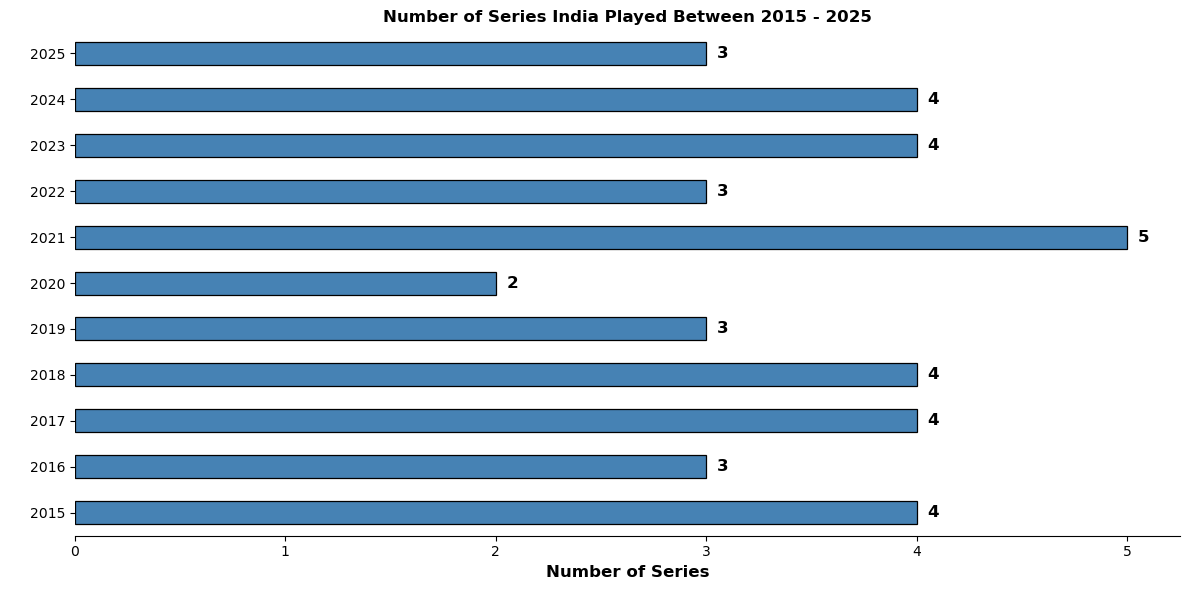

In [19]:
series_per_year = df_series['year'].value_counts().sort_index()
series_per_year.plot(kind = 'barh', figsize = (12,6), color = 'steelblue', linewidth = 0.9, edgecolor = 'black')

sns.despine(left = True)

plt.title(f'Number of Series {country} Played Between 2015 - 2025', fontsize = 12, fontweight = 'bold')
plt.xlabel('Number of Series', fontsize=12, fontweight='bold')
plt.ylabel(" ")

for i, value in enumerate(series_per_year):
    plt.text(
        value + 0.05,   
        i,             
        str(value),  
        va='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [20]:
df_series

,series_id,series_key,match_ids,host_country,num_matches,start_date,end_date,country_wins,opponent_wins,draws,series_result,series_winner,venue_type,year
0,0,Australia-vs-India_Australia_2015,754743,Australia,1,2015-01-06,2015-01-06,0,0,1,Draw,Drawn,Away,2015
1,1,Bangladesh-vs-India_Bangladesh_2015,870729,Bangladesh,1,2015-06-10,2015-06-10,0,0,1,Draw,Drawn,Away,2015
2,2,India-vs-Sri Lanka_Sri Lanka_2015,"895773, 895775, 895777",Sri Lanka,3,2015-08-12,2015-08-28,2,1,0,Win,India,Away,2015
3,3,India-vs-South Africa_India_2015,"903603, 903605, 903607, 903609",India,4,2015-11-05,2015-12-03,3,0,1,Win,India,Home,2015
4,4,India-vs-West Indies_West Indies_2016,"1022593, 1022595, 1022597, 1022599",West Indies,4,2016-07-21,2016-08-18,2,0,2,Win,India,Away,2016
5,5,India-vs-New Zealand_India_2016,"1030213, 1030215, 1030217",India,3,2016-09-22,2016-10-08,3,0,0,Win,India,Home,2016
6,6,England-vs-India_India_2016,"1034809, 1034811, 1034813, 1034815, 1034817",India,5,2016-11-09,2016-12-16,4,0,1,Win,India,Home,2016
7,7,Bangladesh-vs-India_India_2017,1041761,India,1,2017-02-09,2017-02-09,1,0,0,Win,India,Home,2017
8,8,Australia-vs-India_India_2017,"1062573, 1062574, 1062575, 1062576",India,4,2017-02-23,2017-03-25,2,1,1,Win,India,Home,2017
9,9,India-vs-Sri Lanka_Sri Lanka_2017,"1109602, 1109603, 1109604",Sri Lanka,3,2017-07-26,2017-08-12,3,0,0,Win,India,Away,2017


In [21]:
# Home Series
home_series = df_series[df_series['venue_type'] == 'Home']
home_total = len(home_series)
home_wins = len(home_series[home_series['series_result'] == 'Win'])
home_draws = len(home_series[home_series['series_result'] == 'Draw'])
home_loss = len(home_series[home_series['series_result'] == 'Loss'])

print(f"No. of Home series {country} played between {start_year} - {end_year} is {home_total} and won {home_wins} series, drawn {home_draws} series and lost {home_loss} series")

# Away Series
away_series = df_series[df_series['venue_type'] == 'Away']
away_total = len(away_series)
away_wins = len(away_series[away_series['series_result'] == 'Win'])
away_draws = len(away_series[away_series['series_result'] == 'Draw'])
away_loss = len(away_series[away_series['series_result'] == 'Loss'])

print(f"No. of Away series {country} played between {start_year} - {end_year} is {away_total} and won {away_wins} series, drawn {away_draws} series and lost {away_loss} series")

# Neutral Series
neutral_series = df_series[df_series['venue_type'] == 'Neutral']
neutral_total = len(neutral_series)
neutral_wins = len(neutral_series[neutral_series['series_result'] == 'Win'])
neutral_draws = len(neutral_series[neutral_series['series_result'] == 'Draw'])
neutral_loss = len(neutral_series[neutral_series['series_result'] == 'Loss'])

print(f"No. of Neutral series {country} played between {start_year} - {end_year} is {neutral_total} and won {neutral_wins} series, drawn {neutral_draws} series and lost {neutral_loss} series")

No. of Home series India played between 2015 - 2025 is 18 and won 16 series, drawn 0 series and lost 2 series
No. of Away series India played between 2015 - 2025 is 21 and won 9 series, drawn 4 series and lost 8 series
No. of Neutral series India played between 2015 - 2025 is 0 and won 0 series, drawn 0 series and lost 0 series


In [22]:
print(f'No.of Home series {country} Played is {len(df_series[df_series['venue_type'] == 'Home'])}')
print(f'No.of Away series {country} played is {len(df_series[df_series['venue_type'] == 'Away'])} ')
print(f'No.of Series {country} Played in Neutral Condition id {len(df_series[df_series['venue_type'] == 'Neutral'])}')

No.of Home series India Played is 18
No.of Away series India played is 21 
No.of Series India Played in Neutral Condition id 0


In [23]:
# Home series
df_hs = df_series[df_series['venue_type'] == 'Home']

In [24]:
home_summary = pd.DataFrame({
    "Result": ["Win", "Draw", "Loss"],
    "Count": [
        df_hs[df_hs["series_winner"] == country].shape[0],
        df_hs[df_hs["series_winner"] == 'Drawn'].shape[0],
        df_hs[(df_hs["series_winner"] != country) & (df_hs["series_winner"] != 'Drawn')].shape[0]
    ]
})

home_summary

,Result,Count
0,Win,16
1,Draw,0
2,Loss,2


In [25]:
df_as = df_series[df_series['venue_type'] != 'Home']

In [26]:
away_summary = pd.DataFrame({
    "Result": ["Win", "Draw", "Loss"],
    "Count": [
        df_as[df_as["series_winner"] == country].shape[0],
        df_as[df_as["series_winner"] == 'Drawn'].shape[0],
        df_as[(df_as["series_winner"] != country) & (df_as["series_winner"] != 'Drawn')].shape[0]
    ]
})

away_summary

,Result,Count
0,Win,9
1,Draw,4
2,Loss,8


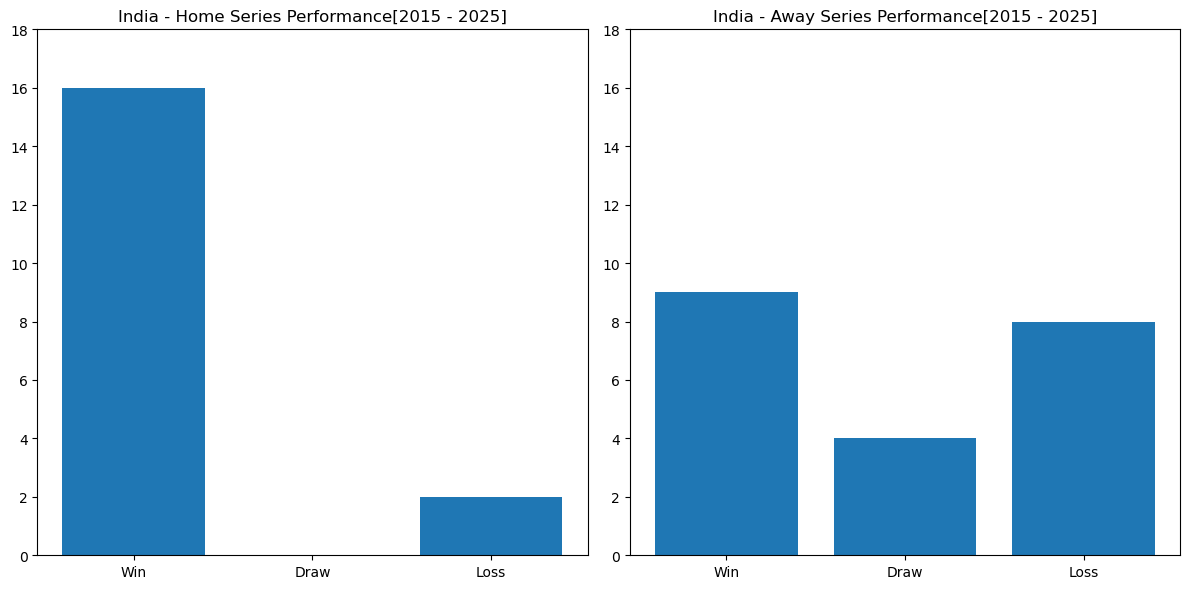

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
fig, axes = plt.subplots(1,2, figsize = (12,6))

#Home Performance
axes[0].bar(home_summary['Result'], home_summary['Count']) #color = 'steelblue')
axes[0].set_title(f'{country} - Home Series Performance[2015 - 2025]')
axes[0].set_ylim(0,18)
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

#Away Performance

axes[1].bar(away_summary['Result'], away_summary['Count']) #color = 'steelblue')
axes[1].set_title(f'{country} - Away Series Performance[2015 - 2025]')
axes[1].set_ylim(0,18)
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
#plot
plt.tight_layout()
plt.show()

In [28]:
home_win_pct = home_summary.loc[0, "Count"] / home_summary["Count"].sum() * 100
away_win_pct = away_summary.loc[0, "Count"] / away_summary["Count"].sum() * 100

print("Home Win %:", round(home_win_pct, 2))
print("Away Win %:", round(away_win_pct, 2))

Home Win %: 88.89
Away Win %: 42.86


In [29]:
grouped = df_series.groupby(["year", "venue_type", "series_result"])["series_id"].count().reset_index()

grouped

,year,venue_type,series_result,series_id
0,2015,Away,Draw,2
1,2015,Away,Win,1
2,2015,Home,Win,1
3,2016,Away,Win,1
4,2016,Home,Win,2
5,2017,Away,Win,1
6,2017,Home,Win,3
7,2018,Away,Loss,2
8,2018,Away,Win,1
9,2018,Home,Win,1


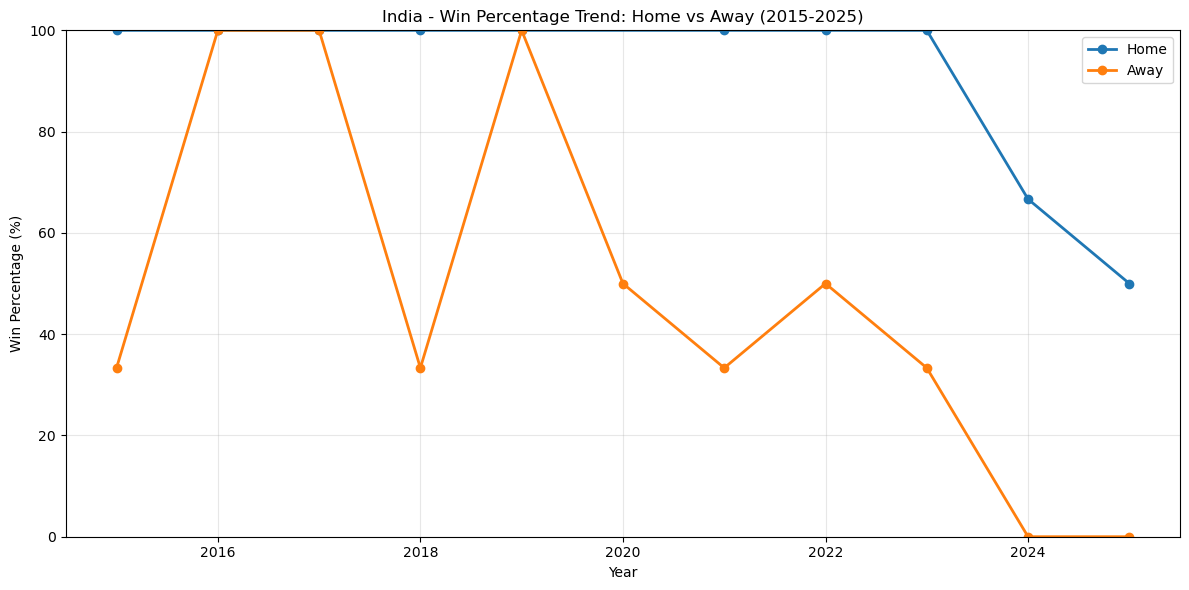

In [30]:
# Calculate win percentage by year for Home and Away
home_trend = df_series[df_series['venue_type'] == 'Home'].groupby('year').agg({
    'series_result': lambda x: (x == 'Win').sum() / len(x) * 100
}).rename(columns={'series_result': 'Win_Percentage'})

away_trend = df_series[df_series['venue_type'] == 'Away'].groupby('year').agg({
    'series_result': lambda x: (x == 'Win').sum() / len(x) * 100
}).rename(columns={'series_result': 'Win_Percentage'})

# Plot
plt.figure(figsize=(12, 6))
plt.plot(home_trend.index, home_trend['Win_Percentage'], marker='o', label='Home', linewidth=2)
plt.plot(away_trend.index, away_trend['Win_Percentage'], marker='o', label='Away', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Win Percentage (%)')
plt.title(f'{country} - Win Percentage Trend: Home vs Away ({start_year}-{end_year})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

“India maintained exceptional home dominance between 2015–2022, winning nearly 89% of home Test series. However, data from 2023 onwards indicates a noticeable reduction in home dominance, alongside weaker away-series performance.”

In [31]:
series_df

,series_key,series_id,Australia,Bangladesh,England,India,Ireland,New Zealand,Pakistan,South Africa,Sri Lanka,West Indies,Zimbabwe,total_matches,series_winner,host_country_x,host_country_y
0,Australia_Bangladesh,1,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,Australia,Bangladesh,Bangladesh
1,Australia_England,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Australia,Australia,Australia
2,Australia_England,2,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Draw,England,England
3,Australia_England,3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Australia,Australia,Australia
4,Australia_England,4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,Draw,England,England
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Sri Lanka_Zimbabwe,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2,Sri Lanka,Zimbabwe,Zimbabwe
284,Sri Lanka_Zimbabwe,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,Sri Lanka,Sri Lanka,Sri Lanka
285,Sri Lanka_Zimbabwe,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,Sri Lanka,Zimbabwe,Zimbabwe
286,West Indies_Zimbabwe,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,West Indies,Zimbabwe,Zimbabwe
